# 2_SWIN_TrafficLight_Classifier.ipynb

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mansamoussa/zebrAssist/blob/master/notebooks/2_SWIN_TrafficLight_Classifier.ipynb)

Fine-tuning **Swin Transformer** (`swin_tiny_patch4_window7_224`) for Traffic Light Classification ( `green`, `red` and `yellow`).

The dataset contains cropped traffic light images with three classes: green, red, yellow.
We train, evaluate, and compare several hyperparameter configurations.


## 1. Project Configuration

After chekcking if we are running this this notebook on Google Colab or locally we will import the required libraries.  
If on Colab, we also install the required packages and mount Google Drive to access the data and save the results.

In [ ]:
# Detect Colab environment
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q timm torchmetrics
    from google.colab import drive
    drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 19.0 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
import os
import torch
import timm
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from datetime import datetime

Here we define the main paths where to find the images and where to store the training runs.  
We also define the image size which is 224 for `swin_tiny_patch4_window7_224`.  
The device is set to GPU if available, otherwise CPU.

In [ ]:
# Configuration
DATA_DIR = "../data/cropped_images" if not IN_COLAB else "/content/drive/MyDrive/Computer_Vision_Project/data/cropped_images"
RUNS_DIR = "../runs/swin_lights" if not IN_COLAB else "/content/drive/MyDrive/Computer_Vision_Project/runs/swin_lights"
# BATCH_SIZE = 32
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Data Preparation

We define the data transformations for training and validation datasets. The data augmentations is specially for the training set to improve the model generalization.  
We then create the datasets and dataloaders using `ImageFolder` from `torchvision.datasets`.    
The are 3 classes: `green`, `red` and `yellow`. Each class is a folder containing the respective images.
In total we have a training set with 43 images and a validation set with 10 images.

We know this is a very small dataset, but this is just for demonstration purposes. In a real-world scenario, we would have a much larger dataset.

In [ ]:
# ## 4. Dataset (with augmentation for training)

# Data augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Ensures all images have the same size (e.g. 224×224)
    transforms.RandomHorizontalFlip(p=0.5), # Flips the image left ↔ right with 50% probability.
    transforms.RandomRotation(15), # Rotates the image randomly by up to ±15 degrees.
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Shifts the image randomly by up to 10% horizontally/vertically.
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1), # Randomly changes brightness, contrast, saturation, and hue.
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)), # Applies blur with a 3×3 kernel and random intensity.
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), # Normalizes pixel values from [0,1] → roughly [-1,1]. Ensures consistency with pretrained model’s expectations.
])


# Minimal preprocessing for validation (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load datasets
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transforms)

# Class names come directly from folder names
CLASS_NAMES = train_dataset.classes  # ["red", "yellow", "green"]
NUM_CLASSES = len(CLASS_NAMES)

# # Dataloaders
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
# val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Classes:", CLASS_NAMES)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


Classes: ['green', 'red', 'yellow']
Train samples: 43
Val samples: 10


Here we displa the 10 validation images with their labels. 3 images are `green`, 5 are `red` and 2 are `yellow`.

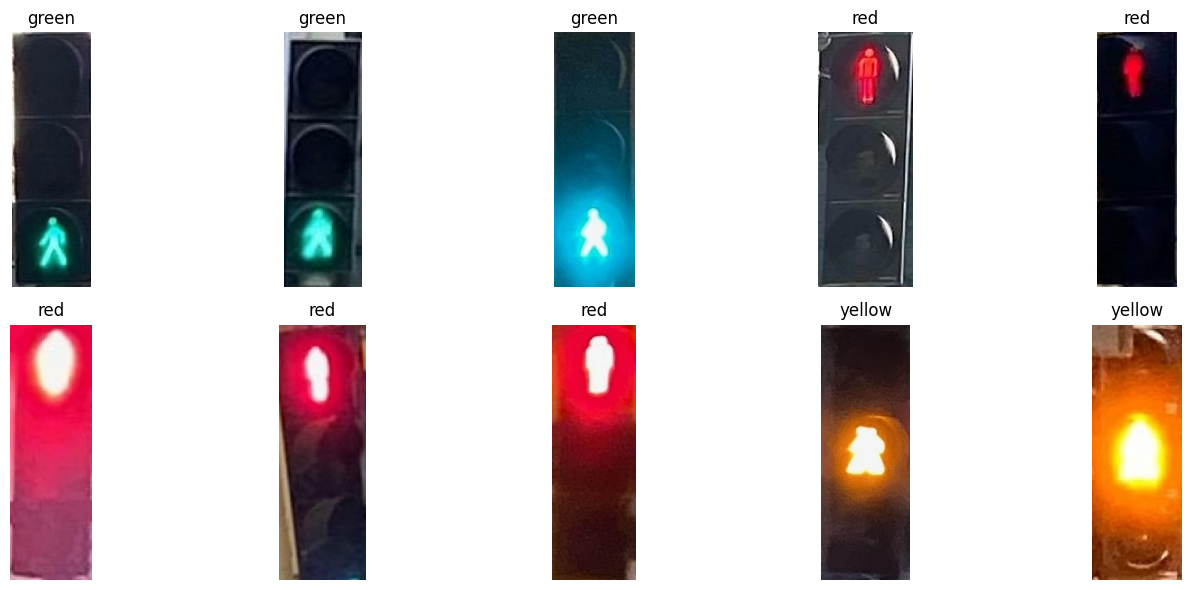

In [ ]:
# ## Display validation images

# Get original dataset without transforms (so we see images as they are)
val_dataset_raw = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=transforms.ToTensor())

# Take first 10 images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img, label = val_dataset_raw[i]
    img = img.permute(1, 2, 0).numpy()  # convert from (C,H,W) to (H,W,C)

    axes[i].imshow(img)
    axes[i].set_title(CLASS_NAMES[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 3. Training Function

We define a reusable function `train_model` that:
- Runs training for a given number of epochs.
- Computes training and validation losses.
- Tracks validation accuracy per epoch.
- Saves the trained model checkpoint to the `RUNS_DIR` folder.
- The function returns training/validation losses and accuracies so we can later plot them.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4, run_name="baseline"):
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=lr)

  train_losses, val_losses, val_accuracies = [], [], []

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
      imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
      optimizer.zero_grad()
      outputs = model(imgs)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    correct, total, val_loss = 0, 0, 0.0
    with torch.no_grad():
      for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    accuracy = correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {accuracy:.4f}")

  # Save model
  run_date = datetime.now().strftime('%Y%m%d_%H%M%S')
  os.makedirs(RUNS_DIR, exist_ok=True)
  save_path = os.path.join(RUNS_DIR, f"{run_date}_{run_name}.pth")
  torch.save(model.state_dict(), save_path)

  return train_losses, val_losses, val_accuracies


## 4. Models Training

Now we can train several models with different hyperparameters. 
Here are the 5 configurations we will try:
| Run Name       | Learning Rate | Epochs | Batch Size |
|----------------|---------------|--------|------------|
| baseline       | 1e-4          | 30     | 8          |
| low_lr         | 5e-5          | 30     | 8          |
| high_lr        | 5e-5          | 30     | 16         |
| bigger_bs      | 1e-4          | 30     | 32         |
| longer_train   | 1e-4          | 50     | 16         |

In [ ]:
# Load pretrained Swin Transformer model
model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=NUM_CLASSES)
model.to(DEVICE);

In [ ]:
# Run Experiments

import pandas as pd
from datetime import datetime
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Define different experiments (hyperparameters)
experiments = {
    "baseline":     {"epochs": 30, "lr": 1e-4, "batch_size": 8},
    "low_lr":       {"epochs": 30, "lr": 5e-5, "batch_size": 8},
    "high_lr":      {"epochs": 30, "lr": 5e-4, "batch_size": 16},
    "bigger_bs":    {"epochs": 30, "lr": 1e-4, "batch_size": 32},
    "longer_train": {"epochs": 50, "lr": 1e-4, "batch_size": 16},
}

# Create runs directory
os.makedirs(RUNS_DIR, exist_ok=True)

# Store results in a list
results_table = []

for run_name, params in experiments.items():
    print(f"\n🚀 Starting run: {run_name}")

    # Update DataLoader if batch size changes
    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=params["batch_size"], shuffle=False, num_workers=2)

    # Fresh model for each run
    model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=NUM_CLASSES)
    model = model.to(DEVICE)

    # Train
    train_losses, val_losses, val_accs = train_model(
        model, train_loader, val_loader,
        epochs=params["epochs"], lr=params["lr"], run_name=run_name
    )

    # ---- Evaluation on validation set ----
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")  # balanced across classes
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True)

    # Store results in table
    results_table.append({
        "run_name": run_name,
        "epochs": params["epochs"],
        "lr": params["lr"],
        "batch_size": params["batch_size"],
        "val_accuracy": acc,
        "val_f1_macro": f1,
        "model_path": save_path,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
    })



🚀 Starting run: baseline
Epoch [1/30] Train Loss: 1.0187, Val Loss: 0.8089, Val Acc: 0.5000
Epoch [2/30] Train Loss: 0.6947, Val Loss: 0.4383, Val Acc: 1.0000
Epoch [3/30] Train Loss: 0.2993, Val Loss: 0.0979, Val Acc: 1.0000
Epoch [4/30] Train Loss: 0.1468, Val Loss: 0.2576, Val Acc: 0.8000
Epoch [5/30] Train Loss: 0.0987, Val Loss: 0.0827, Val Acc: 1.0000
Epoch [6/30] Train Loss: 0.0747, Val Loss: 0.7297, Val Acc: 0.9000
Epoch [7/30] Train Loss: 0.1187, Val Loss: 0.3879, Val Acc: 0.6000
Epoch [8/30] Train Loss: 0.0287, Val Loss: 0.8664, Val Acc: 0.6000
Epoch [9/30] Train Loss: 0.0299, Val Loss: 0.1266, Val Acc: 0.9000
Epoch [10/30] Train Loss: 0.0023, Val Loss: 0.0128, Val Acc: 1.0000
Epoch [11/30] Train Loss: 0.0005, Val Loss: 0.0061, Val Acc: 1.0000
Epoch [12/30] Train Loss: 0.0015, Val Loss: 0.0044, Val Acc: 1.0000
Epoch [13/30] Train Loss: 0.0006, Val Loss: 0.0037, Val Acc: 1.0000
Epoch [14/30] Train Loss: 0.0006, Val Loss: 0.0033, Val Acc: 1.0000
Epoch [15/30] Train Loss: 0.000

This table allows us to quickly identify the best performing models.

In [ ]:
# Convert to DataFrame for easy comparison
results_df = pd.DataFrame(results_table)
results_df

,run_name,epochs,lr,batch_size,val_accuracy,val_f1_macro,model_path,train_losses,val_losses,val_accs
0,baseline,30,0.00010,8,1.0,1.000000,/content/drive/MyDrive/Computer_Vision_Project...,"[1.0186672111352284, 0.6947092637419701, 0.299...","[0.8089333176612854, 0.4383176863193512, 0.097...","[0.5, 1.0, 1.0, 0.8, 1.0, 0.9, 0.6, 0.6, 0.9, ..."
1,low_lr,30,0.00005,8,1.0,1.000000,/content/drive/MyDrive/Computer_Vision_Project...,"[1.0362505316734314, 0.742970327536265, 0.5061...","[1.1375439167022705, 0.9084087610244751, 0.635...","[0.3, 0.7, 0.9, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
2,high_lr,30,0.00050,16,0.7,0.714286,/content/drive/MyDrive/Computer_Vision_Project...,"[1.1711119016011555, 1.231198747952779, 1.1582...","[1.2120635509490967, 1.046975016593933, 1.1245...","[0.3, 0.5, 0.3, 0.5, 0.8, 0.9, 0.7, 1.0, 1.0, ..."
3,bigger_bs,30,0.00010,32,1.0,1.000000,/content/drive/MyDrive/Computer_Vision_Project...,"[1.1792901158332825, 0.9575441479682922, 0.894...","[1.108878493309021, 0.9404058456420898, 0.8831...","[0.3, 0.5, 0.5, 0.5, 0.7, 0.8, 0.9, 0.9, 1.0, ..."
4,longer_train,50,0.00010,16,0.9,0.896296,/content/drive/MyDrive/Computer_Vision_Project...,"[1.0156760017077129, 0.6985402901967367, 0.316...","[0.9216777682304382, 0.6923282146453857, 0.358...","[0.6, 0.8, 0.9, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."


- Baseline (lr=1e-4, bs=8, 30 epochs) → val_acc=1.0, val_f1=1.0

- Low LR (5e-5) → also 1.0, so lowering LR didn’t hurt

- High LR (5e-4) → dropped to 0.7, unstable training

- Bigger batch size (32) → still 1.0, so batch size isn’t the bottleneck

- Longer training (50 epochs) → accuracy dropped to 0.9 (sign of overfitting/instability)

## 5. Validation Plots

For each run, we plot:

- **Loss curves**: training loss vs validation loss across epochs.
- **Validation accuracy curve**: to see how quickly and stably accuracy improves.

The grid of plots makes it easy to visually compare the behavior of different experiments.


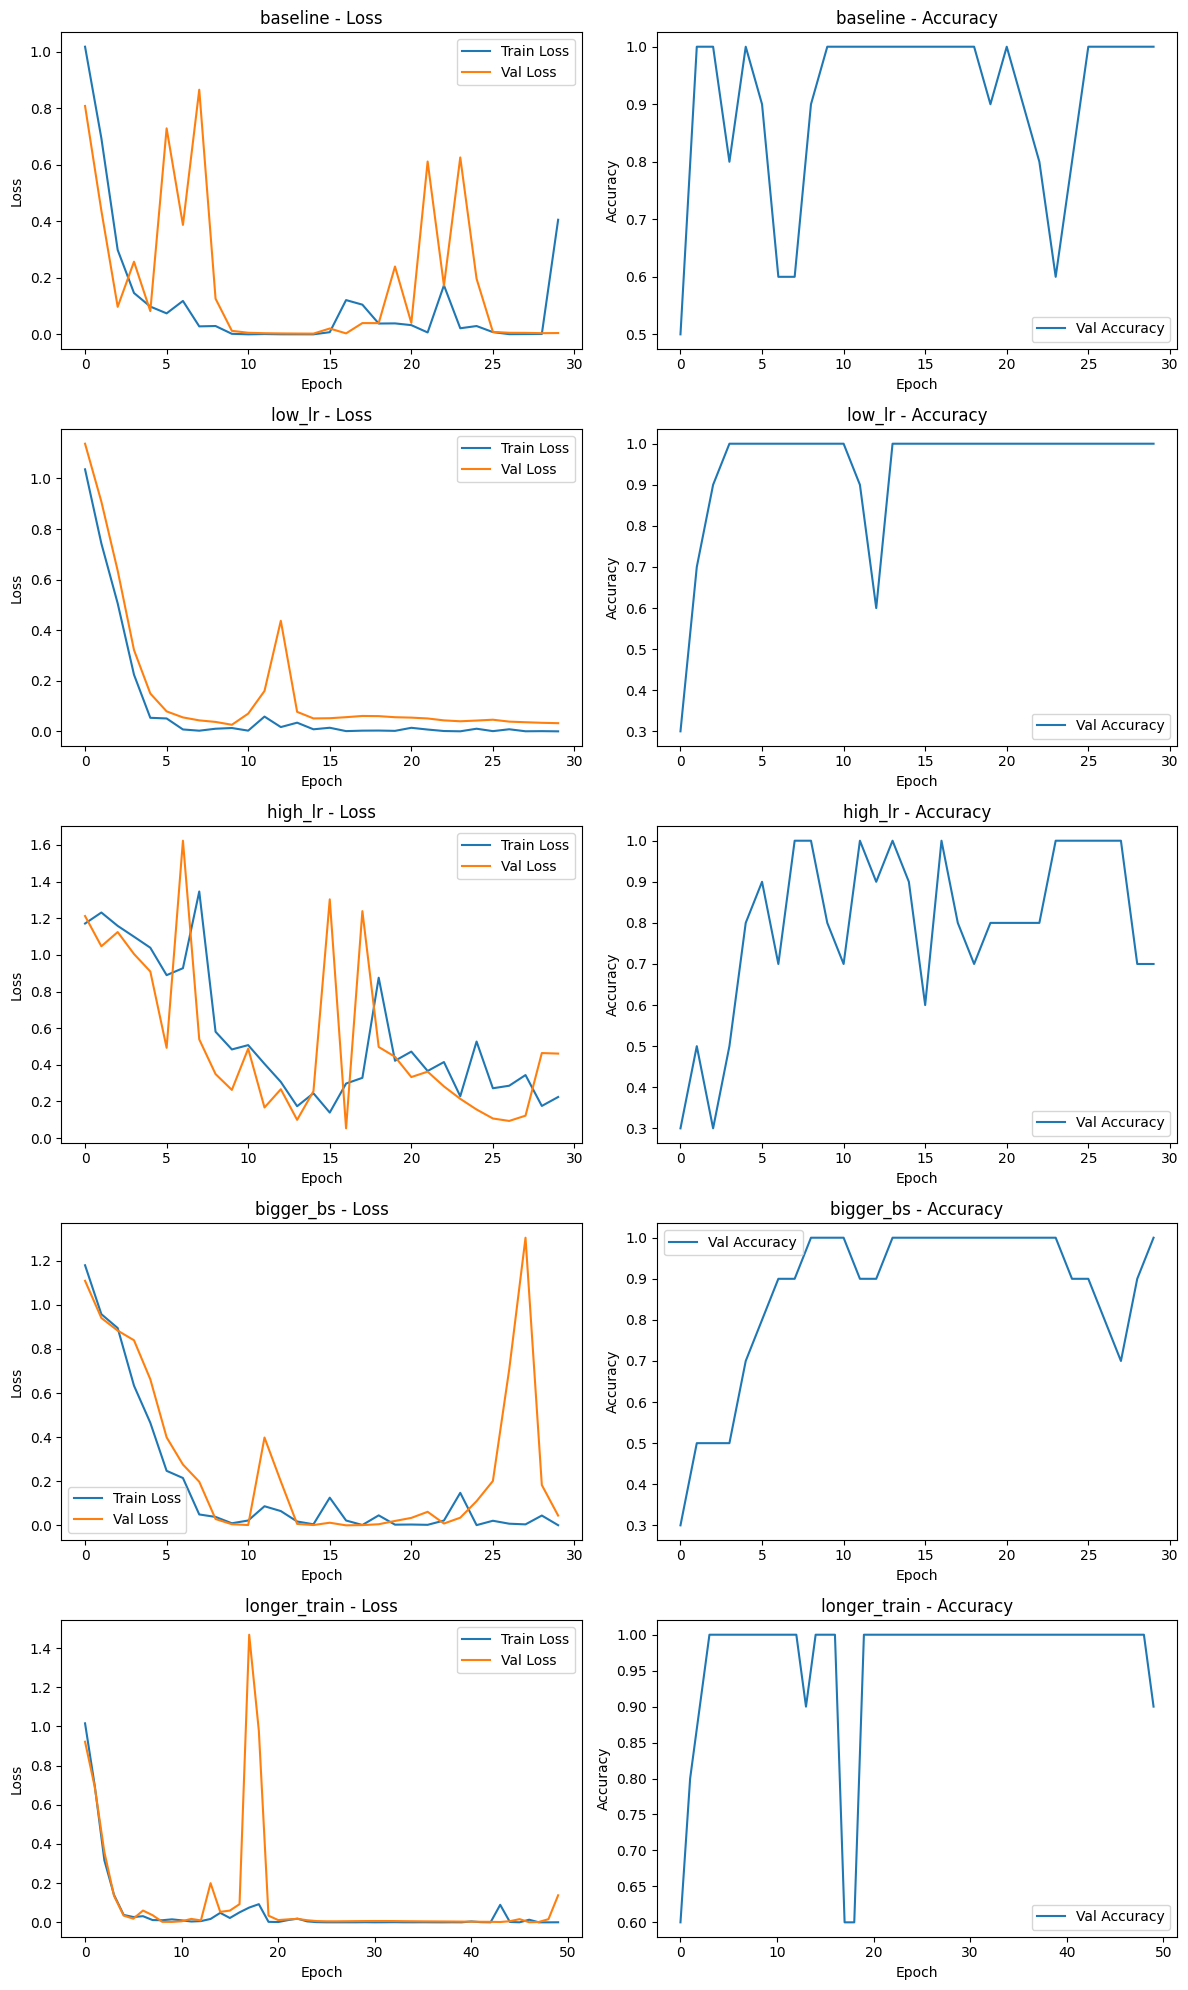

In [ ]:
# ## 8. Plot all experiments in grids

n_runs = len(results_df)
fig, axes = plt.subplots(n_runs, 2, figsize=(12, 4 * n_runs))

for i, row in results_df.iterrows():
    # Loss curves
    axes[i, 0].plot(row["train_losses"], label="Train Loss")
    axes[i, 0].plot(row["val_losses"], label="Val Loss")
    axes[i, 0].set_title(f"{row['run_name']} - Loss")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].legend()

    # Validation accuracy
    axes[i, 1].plot(row["val_accs"], label="Val Accuracy")
    axes[i, 1].set_title(f"{row['run_name']} - Accuracy")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Accuracy")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


1. **Baseline & Low LR**
* Train loss falls quickly and stabilizes near zero.
* Val accuracy fluctuates early but locks at 1.0 by mid-training.
* This shows stable convergence.
2. **High LR**
- Loss curves are noisy and don’t converge smoothly.
- Accuracy bounces a lot and stays lower.
- Confirms too high LR makes optimization unstable.
3. Bigger Batch Size
- Loss decreases slower but still converges.
- Accuracy stabilizes at 1.0 → acceptable.
4. Longer Training
- Initially good, but val accuracy drops slightly at the end.
- Likely overfitting (model memorizing noise in small dataset).

We selected the baseline run and evaluate it on the validation set.  
The confusion matrix shows how well the model performs per class (green, red, yellow).  
This helps identify if certain colors are more difficult to classify.

Loading baseline model: /content/drive/MyDrive/Computer_Vision_Project/runs/swin_lights/20250923_210905_baseline.pth


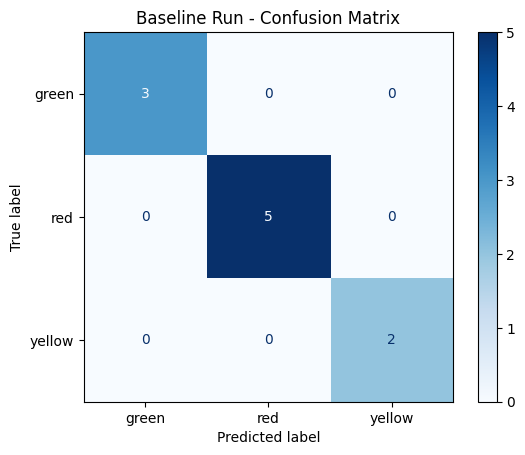

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path


# --- Reload the baseline model ---
try:
  baseline_path = results_df.loc[results_df["run_name"]=="baseline", "model_path"].values[0]
except:
  # baseline_path = "/content/drive/MyDrive/Computer_Vision_Project/runs/swin_lights/20250923_210905_baseline.pth"
  baseline_path = Path(RUNS_DIR) / "20250923_210905_baseline.pth"
print("Loading baseline model:", baseline_path)

baseline_model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False, num_classes=NUM_CLASSES)
baseline_model.load_state_dict(torch.load(baseline_path, map_location=DEVICE))
baseline_model = baseline_model.to(DEVICE)
baseline_model.eval()

# --- Collect predictions on validation set ---
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = baseline_model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Confusion matrix ---
cm = confusion_matrix(all_labels, all_preds, labels=range(NUM_CLASSES))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", values_format="d")
plt.title("Baseline Run - Confusion Matrix")
plt.show()


Again, with such a small dataset, these seem too perfect to be true!  
But the images our model will face won't be a lot different from the training ones.